# EDA on COVID-19 Dataset

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('country_wise_latest.csv')
df.columns = [c.strip().replace(" ", "_").replace("/", "_") for c in df.columns]
df = df.fillna(0)

df.head()


,Country_Region,Confirmed,Deaths,Recovered,Active,New_cases,New_deaths,New_recovered,Deaths___100_Cases,Recovered___100_Cases,Deaths___100_Recovered,Confirmed_last_week,1_week_change,1_week_%_increase,WHO_Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [18]:

# Dataset Information
print(df.info())

# Statistical Summary
print(df.describe())

# Recovery and Death Rate
df['Recovery_Rate'] = (df['Recovered'] / df['Confirmed']) * 100
df['Death_Rate'] = (df['Deaths'] / df['Confirmed']) * 100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country_Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New_cases               187 non-null    int64  
 6   New_deaths              187 non-null    int64  
 7   New_recovered           187 non-null    int64  
 8   Deaths___100_Cases      187 non-null    float64
 9   Recovered___100_Cases   187 non-null    float64
 10  Deaths___100_Recovered  187 non-null    float64
 11  Confirmed_last_week     187 non-null    int64  
 12  1_week_change           187 non-null    int64  
 13  1_week_%_increase       187 non-null    float64
 14  WHO_Region              187 non-null    ob

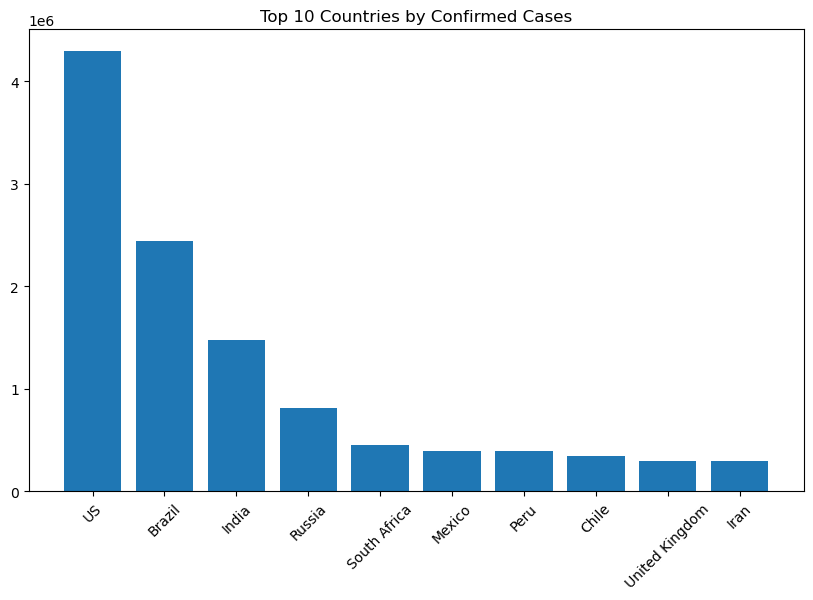

In [19]:

top10 = df.sort_values('Confirmed', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top10['Country_Region'], top10['Confirmed'])
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Confirmed Cases')
plt.show()


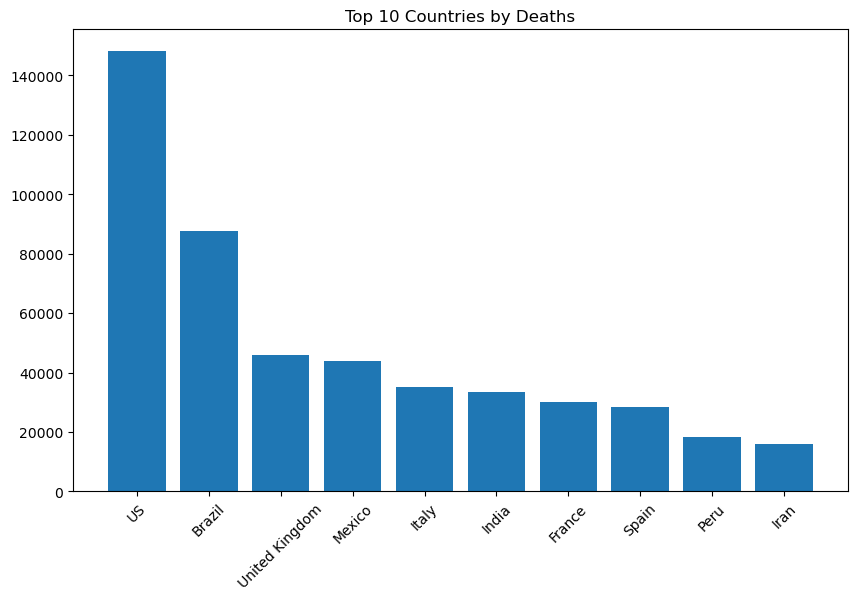

In [20]:

topd = df.sort_values('Deaths', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(topd['Country_Region'], topd['Deaths'])
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Deaths')
plt.show()


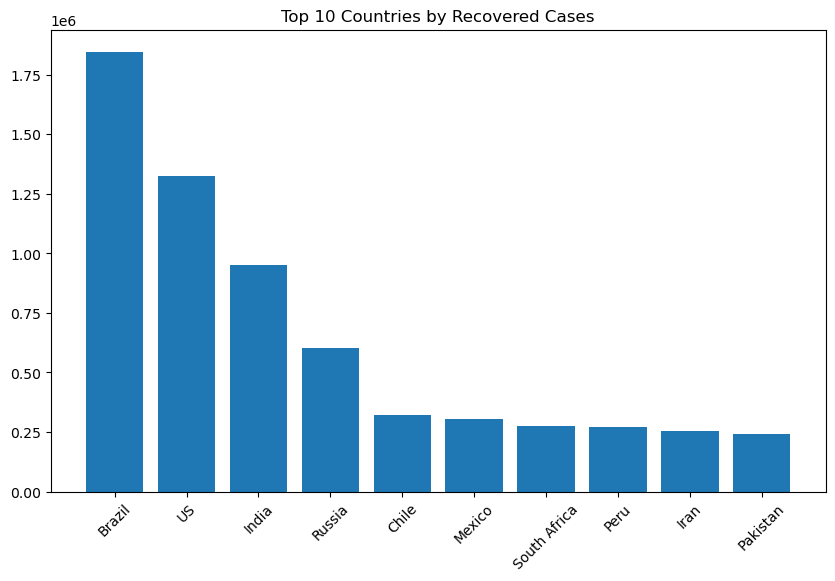

In [21]:

topr = df.sort_values('Recovered', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(topr['Country_Region'], topr['Recovered'])
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Recovered Cases')
plt.show()


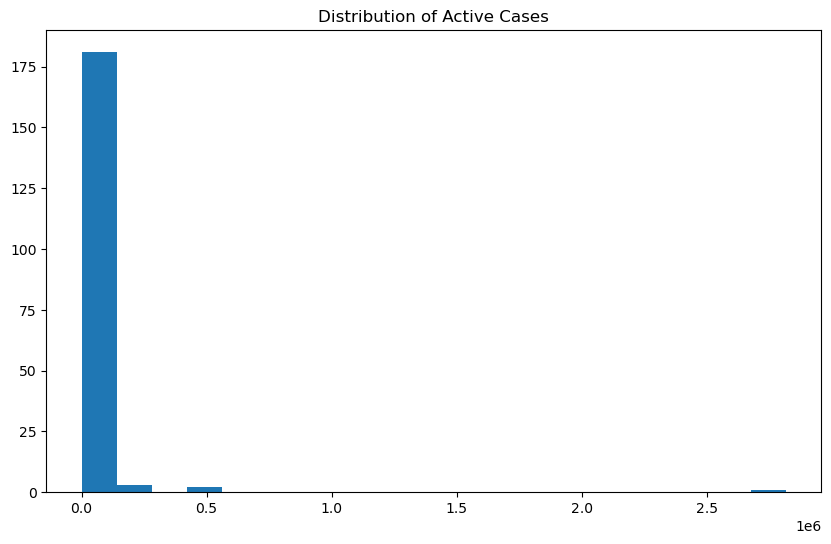

In [22]:

plt.figure(figsize=(10,6))
plt.hist(df['Active'], bins=20)
plt.title('Distribution of Active Cases')
plt.show()


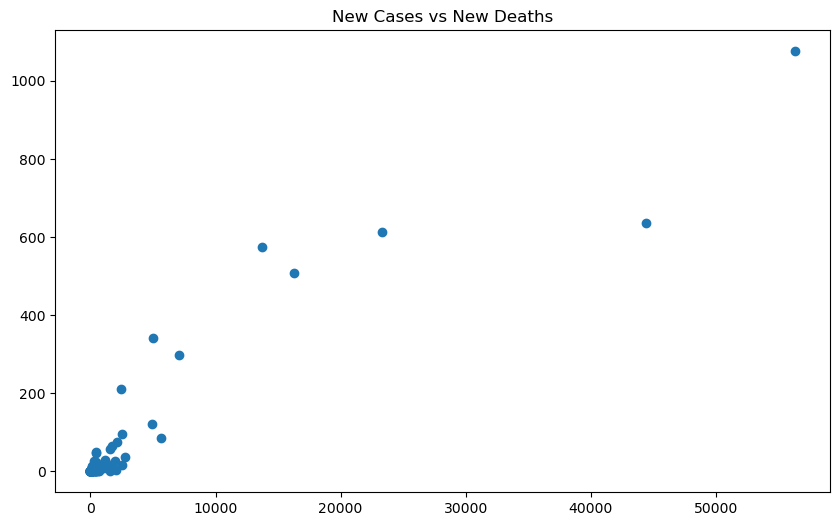

In [23]:

plt.figure(figsize=(10,6))
plt.scatter(df['New_cases'], df['New_deaths'])
plt.title('New Cases vs New Deaths')
plt.show()


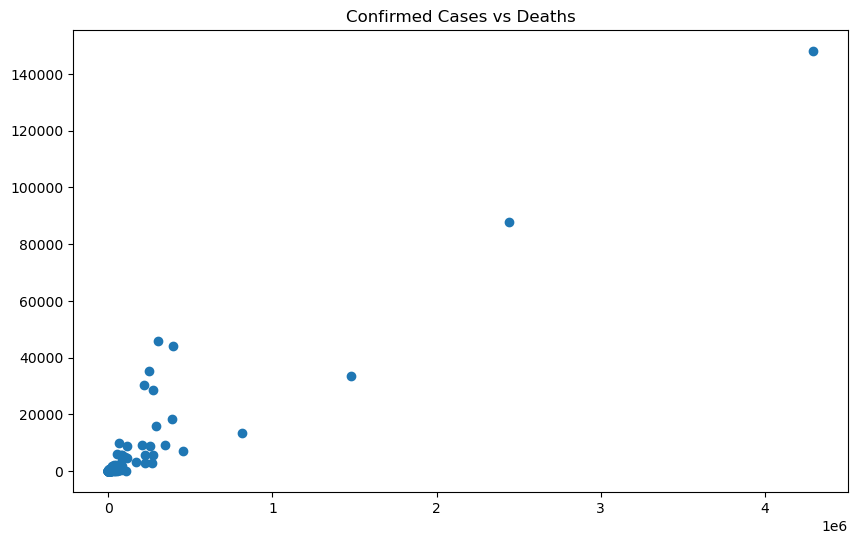

In [24]:

plt.figure(figsize=(10,6))
plt.scatter(df['Confirmed'], df['Deaths'])
plt.title('Confirmed Cases vs Deaths')
plt.show()


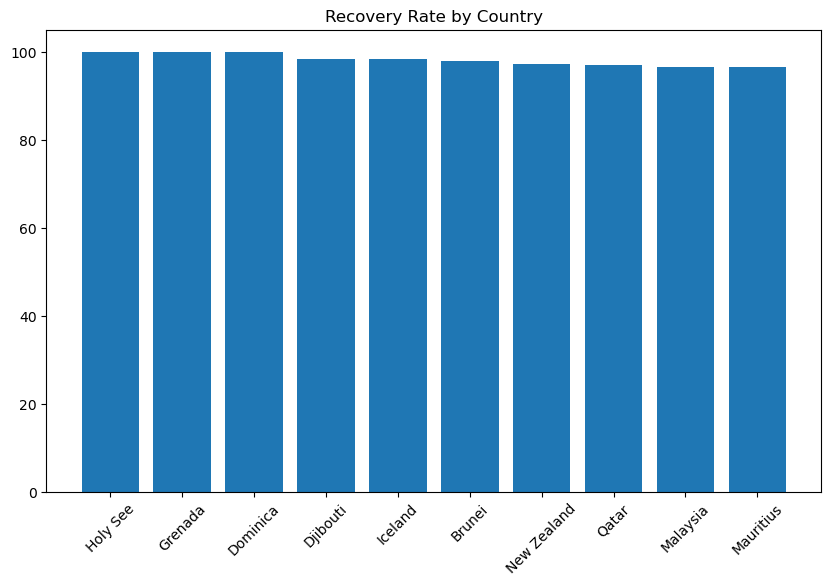

In [25]:

top_rr = df.sort_values('Recovery_Rate', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top_rr['Country_Region'], top_rr['Recovery_Rate'])
plt.xticks(rotation=45)
plt.title('Recovery Rate by Country')
plt.show()


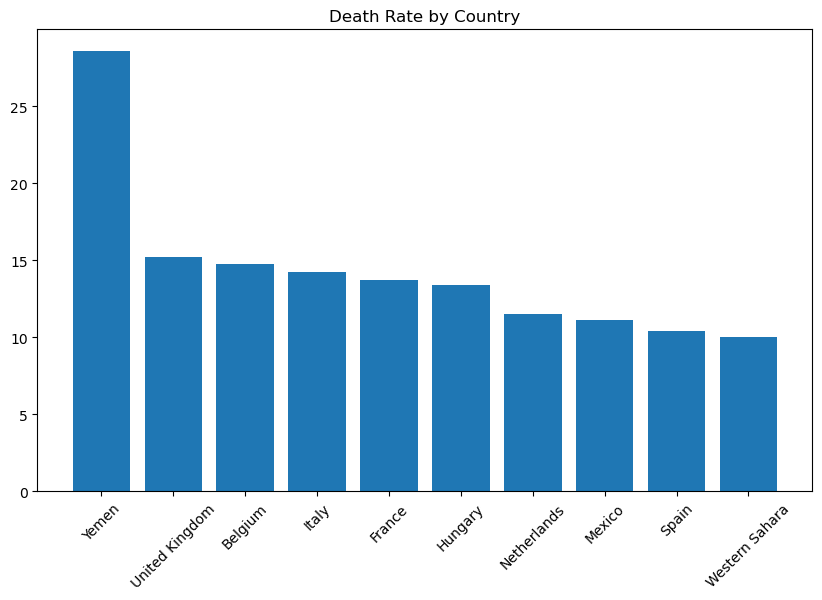

In [26]:

top_dr = df.sort_values('Death_Rate', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top_dr['Country_Region'], top_dr['Death_Rate'])
plt.xticks(rotation=45)
plt.title('Death Rate by Country')
plt.show()


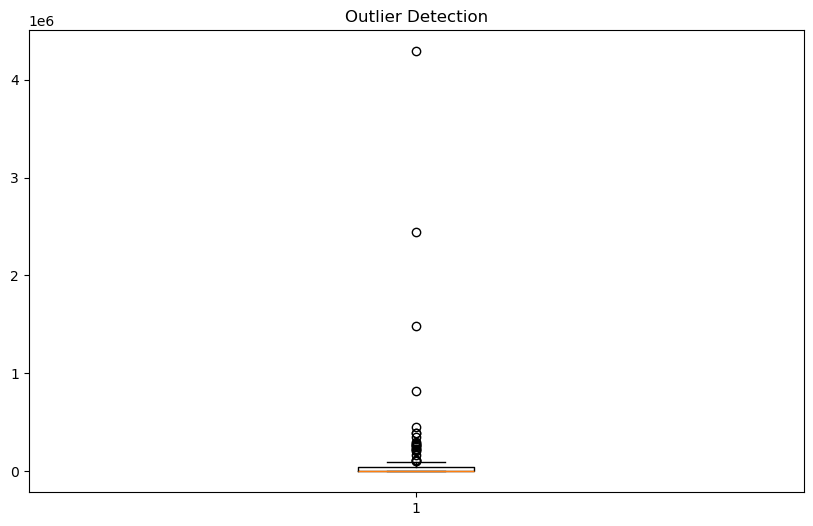

In [27]:

plt.figure(figsize=(10,6))
plt.boxplot(df['Confirmed'])
plt.title('Outlier Detection')
plt.show()


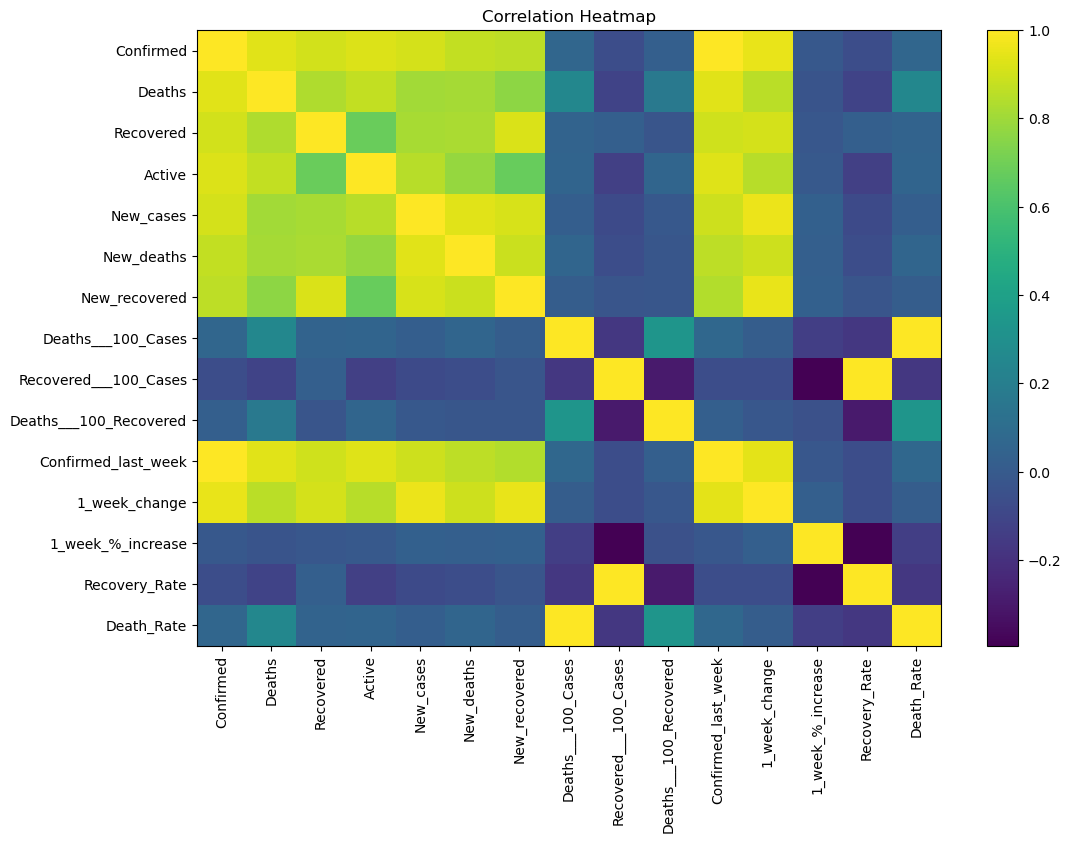

In [28]:

corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


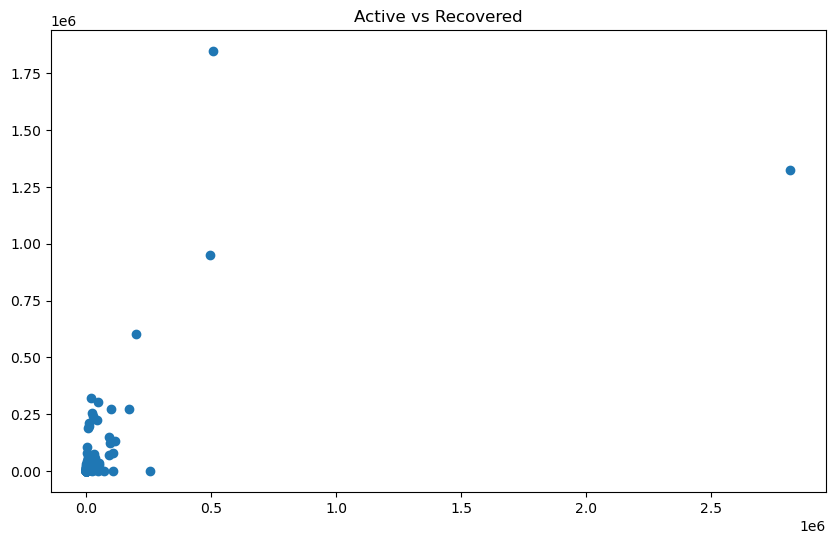

In [29]:

plt.figure(figsize=(10,6))
plt.scatter(df['Active'], df['Recovered'])
plt.title('Active vs Recovered')
plt.show()


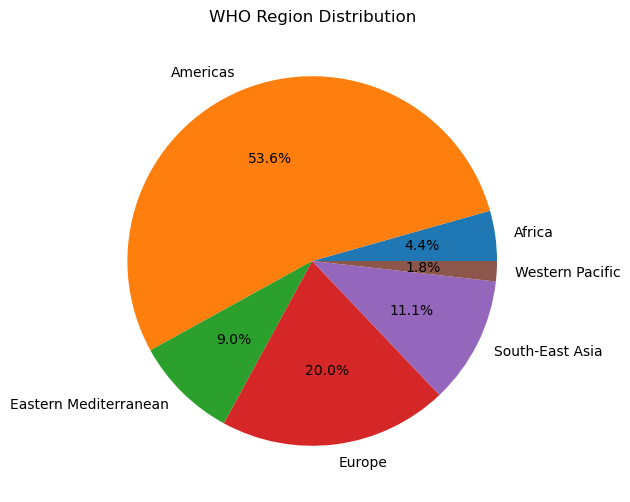

In [30]:

region = df.groupby('WHO_Region')['Confirmed'].sum()
plt.figure(figsize=(10,6))
plt.pie(region, labels=region.index, autopct='%1.1f%%')
plt.title('WHO Region Distribution')
plt.show()



# Final Insights

1. Countries with high confirmed cases generally experienced higher death counts.
2. Several countries are outliers with extremely high confirmed cases compared to the global average.
3. Recovery rates differ significantly across countries, showing differences in healthcare systems and response effectiveness.
